# PCA on Correlation Matrices (Train Fit, Test Evaluation)
Fit PCA on flattened train correlation matrices and reconstruct the test matrices using the learned components.
Compute reconstruction errors (MSE, MAE, Frobenius) on the test set, while explained variance is reported from the train fit.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder under `data/processed/dataset/`.
The folder must contain `train.pt`, `val.pt`, and `test.pt` with correlation matrices already split.

In [12]:
# Dataset path configuration
FILE_NAME = 'data_00_20'
WINDOW_SIZE = 252
STRIDE = 5
FORWARD_DAYS = 21
DATASET_DIR = Path('../data/processed') / FILE_NAME / 'dataset' / f'{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}' / f'{FORWARD_DAYS}_days_gap'

TRAIN_FILE = DATASET_DIR / 'train.pt'
VAL_FILE = DATASET_DIR / 'val.pt'
TEST_FILE = DATASET_DIR / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(f'File not found: {split_path.resolve()}')

print(f'Dataset folder: {DATASET_DIR.name}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Dataset folder: 21_days_gap
Train: train.pt | Val: val.pt | Test: test.pt


In [13]:
def load_dataset_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k not in ('corr_tensor', 'cholesky_L')}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_dataset_payload(TRAIN_FILE)
val_corr, val_meta = load_dataset_payload(VAL_FILE)
test_corr, test_meta = load_dataset_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')


print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (679, 100, 100)
val_corr shape:   (145, 100, 100)
test_corr shape:  (146, 100, 100)


## Step 2: Prepare Train/Val/Test Matrices
Each correlation matrix is loaded as N x N.
If PCA_INPUT='cholesky_lower', PCA uses the flattened lower-triangular Cholesky factors (including diagonal).
If PCA_INPUT='corr', PCA uses the flattened lower-triangular correlations (excluding diagonal).
The validation split is loaded for completeness but not used later.

In [14]:
train_np = train_corr.numpy()
val_np = val_corr.numpy()
test_np = test_corr.numpy()

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]

print(f'Train matrices: {n_train}')
print(f'Val matrices:   {n_val}')
print(f'Test matrices:  {n_test}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')


feature_dim = n_assets * (n_assets - 1) // 2

print(f'Flattened feature dimension: {feature_dim}')

Train matrices: 679
Val matrices:   145
Test matrices:  146
Assets per matrix (N): 100
Each input matrix shape: (100, 100)
Flattened feature dimension: 4950


## Step 3: Fit PCA on Train, Reconstruct Test
For every matrix:
- If PCA_INPUT='cholesky_lower', flatten the lower-triangular Cholesky factor (including diagonal)
- If PCA_INPUT='corr', flatten the lower-triangular correlations (excluding diagonal)
- Fit PCA on the train split only
- Apply PCA to the test split and inverse transform to reconstruct
If using Cholesky, reconstructed correlation matrices are obtained via $L L^T$ and re-normalized to unit diagonal;
if using correlations, the lower triangle is mirrored and the diagonal is set to 1.
Errors are computed on the test split; explained variance is from the train fit.

In [15]:
def apply_pca(
    train_corr,
    eval_corr,
    n_components,
 ):
    
    if train_corr.ndim != 3 or train_corr.shape[1] != train_corr.shape[2]:
        raise ValueError(f'Expected train shape (n_samples, N, N), got {train_corr.shape}')
    if eval_corr.ndim != 3 or eval_corr.shape[1] != eval_corr.shape[2]:
        raise ValueError(f'Expected eval shape (n_samples, N, N), got {eval_corr.shape}')

    n_train, n_assets, _ = train_corr.shape
    n_eval, n_assets_eval, _ = eval_corr.shape
    if n_assets_eval != n_assets:
        raise ValueError(f'Train/eval asset dims mismatch: {train_corr.shape} vs {eval_corr.shape}')

    
    tril_idx = np.tril_indices(n_assets, k=-1)
    train_flat = train_corr[:, tril_idx[0], tril_idx[1]]
    eval_flat = eval_corr[:, tril_idx[0], tril_idx[1]]

    n_features = train_flat.shape[1]
    if not (1 <= n_components <= min(n_train, n_features)):
        raise ValueError(f'n_components must be in [1, {min(n_train, n_features)}]')

    # Fit PCA on train, then reconstruct eval
    pca = PCA(n_components=n_components)
    pca.fit(train_flat)
    eval_recon = pca.inverse_transform(pca.transform(eval_flat))

    
    recon_corr = np.zeros((n_eval, n_assets, n_assets), dtype=eval_recon.dtype)
    recon_corr[:, tril_idx[0], tril_idx[1]] = eval_recon
    recon_corr = recon_corr + np.transpose(recon_corr, (0, 2, 1))
    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return {
        'recon_corr': recon_corr,
        'explained_variance': pca.explained_variance_ratio_,
        'pca': pca,
    }

In [16]:
N_COMPONENTS = 3
max_components = min(n_train, feature_dim)

pca_out = apply_pca(
    train_np,
    test_np,
    n_components=N_COMPONENTS,
)
recon_corr = pca_out['recon_corr']
mean_explained_ratio = pca_out['explained_variance']
pca = pca_out['pca']

var_percent = mean_explained_ratio.sum() * 100
print('--- PCA Reconstruction (train fit, test eval) ---')
print(f'Train tensor shape:         {train_np.shape}')
print(f'Test tensor shape:          {test_np.shape}')
print(f'Reconstructed test shape:   {recon_corr.shape}')
print(f'Components kept (K):        {N_COMPONENTS}')
print(f'Cumulative explained variance (train): {var_percent:.2f}%\n')
for idx, var in enumerate(mean_explained_ratio):
    print(f'Variance PC{idx+1} (train): {(var * 100):.2f}%')

--- PCA Reconstruction (train fit, test eval) ---
Train tensor shape:         (679, 100, 100)
Test tensor shape:          (146, 100, 100)
Reconstructed test shape:   (146, 100, 100)
Components kept (K):        3
Cumulative explained variance (train): 79.71%

Variance PC1 (train): 69.49%
Variance PC2 (train): 5.61%
Variance PC3 (train): 4.61%


## Step 4: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.1935 0.0427 0.0799 0.2965]
 [0.1935 1.     0.1672 0.2581 0.2881]
 [0.0427 0.1672 1.     0.2104 0.1808]
 [0.0799 0.2581 0.2104 1.     0.1444]
 [0.2965 0.2881 0.1808 0.1444 1.    ]]
Reconstructed Matrix:
[[1.     0.1944 0.1548 0.149  0.2195]
 [0.1944 1.     0.1632 0.163  0.2468]
 [0.1548 0.1632 1.     0.1988 0.1642]
 [0.149  0.163  0.1988 1.     0.179 ]
 [0.2195 0.2468 0.1642 0.179  1.    ]]
Error Matrix:
[[ 0.      0.0009  0.112   0.0691 -0.077 ]
 [ 0.0009  0.     -0.004  -0.0951 -0.0413]
 [ 0.112  -0.004   0.     -0.0116 -0.0167]
 [ 0.0691 -0.0951 -0.0116  0.      0.0345]
 [-0.077  -0.0413 -0.0167  0.0345  0.    ]]
Sample index: 0
MSE: 0.010280 | MAE: 0.079411 | Frobenius: 10.139263
Error range - Min: -0.398486 | Max: 0.489806


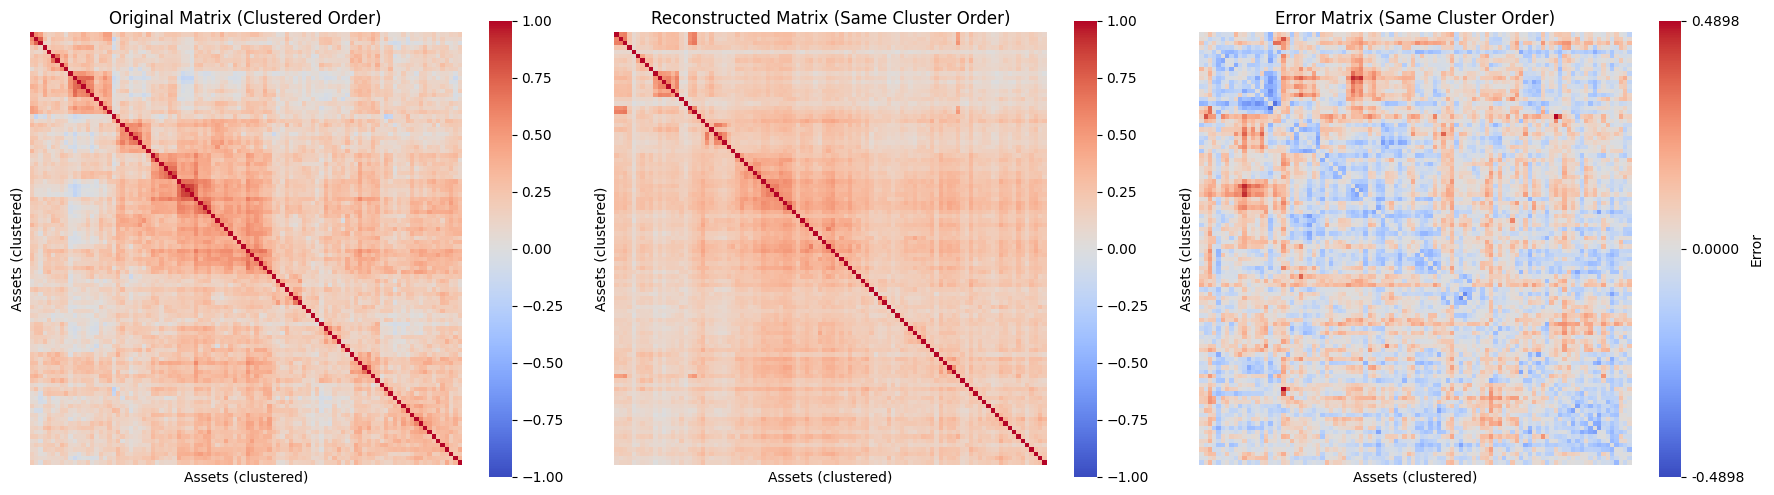

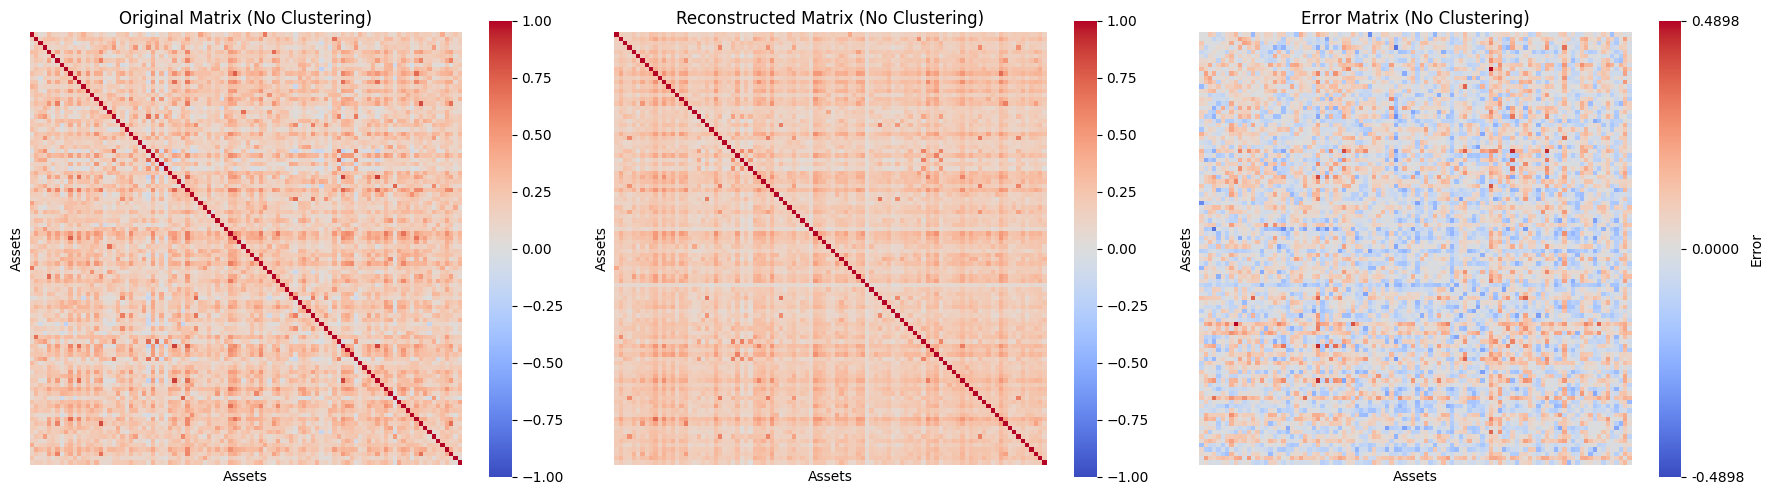

In [17]:
SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_mat = test_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

# Use the same colormap for all matrices.
shared_cmap = 'coolwarm'

# Error scale must be symmetric around zero: [-max|err|, +max|err|]
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

# Clustered heatmaps in a single side-by-side figure (without dendrograms).
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(err_mat, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max, cmap=shared_cmap, center=0, square=True, cbar_kws={'label': 'Error'})
axes[2].set_title('Error Matrix (No Clustering)')
# Set colorbar ticks for standard heatmap
cbar = hm.collections[0].colorbar
cbar.set_ticks([-err_abs_max, 0, err_abs_max])
cbar.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 5: Calculate Reconstruction Errors (Train/Test)
Measure reconstruction quality on the train and test splits using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [18]:

def rebuild_matrices(recon_flat: np.ndarray, n_assets: int):
    """Prende un array piatto (N, 4950) e lo trasforma in (N, 100, 100) simmetrico con 1 sulla diagonale."""
    n_samples = recon_flat.shape[0]
    recon_corr = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)
    tril_idx = np.tril_indices(n_assets, k=-1)

    # Inserisce i valori sotto e sopra la diagonale (simmetria)
    recon_corr[:, tril_idx[0], tril_idx[1]] = recon_flat
    recon_corr[:, tril_idx[1], tril_idx[0]] = recon_flat

    # Inserisce gli 1 sulla diagonale
    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return recon_corr

def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    if original.shape != reconstructed.shape:
        raise ValueError(f'Input shapes mismatch: {original.shape} vs {reconstructed.shape}')

    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })
    
    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

# --- ESECUZIONE SUI 3 DATASET ---
tril_idx = np.tril_indices(n_assets, k=-1)

# 1. TRAIN SET
train_flat = train_np[:, tril_idx[0], tril_idx[1]]
recon_train_flat = pca.inverse_transform(pca.transform(train_flat))
recon_train_matrices = rebuild_matrices(recon_train_flat, n_assets) # <-- RICOSTRUZIONE MATRICE

errors_df_train, errors_stats_train = reconstruction_errors(train_np, recon_train_matrices)
print('--- Matrix Reconstruction Errors (Train Set) ---')
display(errors_stats_train)

# 2. VAL SET
val_flat = val_np[:, tril_idx[0], tril_idx[1]]
recon_val_flat = pca.inverse_transform(pca.transform(val_flat))
recon_val_matrices = rebuild_matrices(recon_val_flat, n_assets) # <-- RICOSTRUZIONE MATRICE

errors_df_val, errors_stats_val = reconstruction_errors(val_np, recon_val_matrices)
print('\n--- Matrix Reconstruction Errors (Validation Set) ---')
display(errors_stats_val)

# 3. TEST SET
test_flat = test_np[:, tril_idx[0], tril_idx[1]]
recon_test_flat = pca.inverse_transform(pca.transform(test_flat))
recon_test_matrices = rebuild_matrices(recon_test_flat, n_assets) # <-- RICOSTRUZIONE MATRICE

errors_df_test, errors_stats_test = reconstruction_errors(test_np, recon_test_matrices)
print('\n--- Matrix Reconstruction Errors (Test Set) ---')
display(errors_stats_test)

--- Matrix Reconstruction Errors (Train Set) ---


,mean,std,min,median,max
MSE,0.004555,0.001187,0.002900,0.004299,0.010619
MAE,0.052751,0.006663,0.041485,0.051819,0.082507
Frobenius,6.698426,0.824503,5.385392,6.556927,10.304919



--- Matrix Reconstruction Errors (Validation Set) ---


,mean,std,min,median,max
MSE,0.011958,0.002350,0.007765,0.011322,0.015584
MAE,0.085835,0.007331,0.069579,0.084845,0.097400
Frobenius,10.882155,1.077873,8.812021,10.640630,12.483718



--- Matrix Reconstruction Errors (Test Set) ---


,mean,std,min,median,max
MSE,0.014715,0.004188,0.009879,0.012914,0.022900
MAE,0.094388,0.012968,0.077720,0.089826,0.118336
Frobenius,12.017070,1.660789,9.939420,11.363921,15.132669


## Step 7: Error Analysis Across Components
Sweep over different numbers of K components, fitting PCA on the train split and evaluating reconstruction errors on the train and test sets.

In [19]:
import json

candidate_components = [3, 10, 20, 50, 100, 614]
n_train = train_np.shape[0]
feature_dim = (n_assets * (n_assets - 1)) // 2

max_components = min(n_train, feature_dim)
candidate_components = [c for c in candidate_components if c <= max_components]
print(f'Evaluating reconstruction errors for components: {candidate_components}')


def rebuild_matrices(recon_flat: np.ndarray, n_assets: int):
    """Prende un array piatto (N, feature_dim) e lo trasforma in (N, n_assets, n_assets) simmetrico con 1 sulla diagonale."""
    n_samples = recon_flat.shape[0]
    recon_corr = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)
    tril_idx = np.tril_indices(n_assets, k=-1)

    recon_corr[:, tril_idx[0], tril_idx[1]] = recon_flat
    recon_corr[:, tril_idx[1], tril_idx[0]] = recon_flat

    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return recon_corr


# 1. Carica i payload separati per ogni split (assicurati di avere i path corretti)
base_payloads = {
    'train': torch.load(TRAIN_FILE, map_location='cpu'),
    'val': torch.load(VAL_FILE, map_location='cpu'),
    'test': torch.load(TEST_FILE, map_location='cpu')
}

# Funzione helper per uniformare i payload
def get_template(payload):
    return payload if isinstance(payload, dict) else {'corr_tensor': payload}

payload_templates = {k: get_template(v) for k, v in base_payloads.items()}


def extract_tickers(payloads: dict):
    for payload in payloads.values():
        if not isinstance(payload, dict):
            continue
        if 'tickers' in payload:
            return payload.get('tickers')
        meta = payload.get('meta') or payload.get('metadata')
        if isinstance(meta, dict) and 'tickers' in meta:
            return meta.get('tickers')
    return None


tickers = extract_tickers(payload_templates)

splits_np = {
    'train': train_np,
    'val': val_np,
    'test': test_np,
}

tril_idx = np.tril_indices(n_assets, k=-1)

rows = []
sweep_payload = []
stat_cols = ["mean", "std", "min", "median", "max"]

for n_comp in candidate_components:
    recon_dir = Path(
        f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/{FORWARD_DAYS}_days_gap/PCA/PCA_{n_comp}dim/analysis_outputs'
    )
    recon_dir.mkdir(parents=True, exist_ok=True)

    # Fit PCA solo sul train
    train_flat = splits_np['train'][:, tril_idx[0], tril_idx[1]]
    pca = PCA(n_components=n_comp)
    pca.fit(train_flat)

    explained_ratio = pca.explained_variance_ratio_
    cum_explained_ratio = float(explained_ratio.sum())

    split_stats = {}

    for set_name, split_np in splits_np.items():
        split_flat = split_np[:, tril_idx[0], tril_idx[1]]
        split_recon_flat = pca.inverse_transform(pca.transform(split_flat))
        split_recon_corr = rebuild_matrices(split_recon_flat, n_assets)

        _, split_matrix_stats = reconstruction_errors(split_np, split_recon_corr)
        split_stats[set_name] = split_matrix_stats

        # --- SALVATAGGIO TENSORI ---
        extended_payload = dict(payload_templates[set_name])
        extended_payload['corr_tensor_reconstructed'] = torch.from_numpy(split_recon_corr).float()

        if tickers is not None:
            extended_payload['tickers'] = tickers

        output_path = recon_dir / f'{set_name}_reconstructed_PCA_{n_comp}dim.pt'
        torch.save(extended_payload, output_path)
        print(f'Saved {set_name} reconstructed matrices for K={n_comp}: {output_path.resolve()}')

    # --- EXTRACTING STATS ---
    def extract_stats(stats_df):
        stats_dict = {}
        for metric in ["MSE", "MAE", "Frobenius"]:
            if metric in stats_df.index:
                stats_dict[metric] = {k: float(stats_df.loc[metric, stat_cols][k]) for k in stat_cols}
        return stats_dict

    train_err_stats = extract_stats(split_stats['train'])
    val_err_stats = extract_stats(split_stats['val'])
    test_err_stats = extract_stats(split_stats['test'])

    # --- APPEND TO DATAFRAME ROWS ---
    rows.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'Train_matrix_MSE_mean': float(train_err_stats["MSE"]["mean"]),
        'Train_matrix_MAE_mean': float(train_err_stats["MAE"]["mean"]),
        'Train_matrix_Frobenius_mean': float(train_err_stats["Frobenius"]["mean"]),
        'Val_matrix_MSE_mean': float(val_err_stats["MSE"]["mean"]),
        'Val_matrix_MAE_mean': float(val_err_stats["MAE"]["mean"]),
        'Val_matrix_Frobenius_mean': float(val_err_stats["Frobenius"]["mean"]),
        'Test_matrix_MSE_mean': float(test_err_stats["MSE"]["mean"]),
        'Test_matrix_MAE_mean': float(test_err_stats["MAE"]["mean"]),
        'Test_matrix_Frobenius_mean': float(test_err_stats["Frobenius"]["mean"]),
    })

    # --- APPEND TO JSON PAYLOAD ---
    sweep_payload.append({
        'n_components': n_comp,
        'mean_explained_variance': cum_explained_ratio,
        'reconstruction_errors_on_matrix_train': train_err_stats,
        'reconstruction_errors_on_matrix_val': val_err_stats,
        'reconstruction_errors_on_matrix_test': test_err_stats,
    })

sweep_df = pd.DataFrame(rows)

# Print Summary Tables
train_cols = ['n_components', 'mean_explained_variance', 'Train_matrix_MSE_mean', 'Train_matrix_MAE_mean', 'Train_matrix_Frobenius_mean']
val_cols = ['n_components', 'mean_explained_variance', 'Val_matrix_MSE_mean', 'Val_matrix_MAE_mean', 'Val_matrix_Frobenius_mean']
test_cols = ['n_components', 'mean_explained_variance', 'Test_matrix_MSE_mean', 'Test_matrix_MAE_mean', 'Test_matrix_Frobenius_mean']

print('\n--- Train summary (Matrix) ---')
display(sweep_df[train_cols])

print('\n--- Validation summary (Matrix) ---')
display(sweep_df[val_cols])

print('\n--- Test summary (Matrix) ---')
display(sweep_df[test_cols])

# Save JSON
sweep_path = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/{FORWARD_DAYS}_days_gap/PCA/reconstruction_errors.json')
sweep_path.parent.mkdir(parents=True, exist_ok=True)
with open(sweep_path, 'w') as f:
    json.dump(sweep_payload, f, indent=2)
print(f'\nSaved sweep_payload JSON to: {sweep_path.resolve()}')

Evaluating reconstruction errors for components: [3, 10, 20, 50, 100, 614]
Saved train reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\PCA_3dim\analysis_outputs\train_reconstructed_PCA_3dim.pt
Saved val reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\PCA_3dim\analysis_outputs\val_reconstructed_PCA_3dim.pt
Saved test reconstructed matrices for K=3: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\PCA_3dim\analysis_outputs\test_reconstructed_PCA_3dim.pt
Saved train reconstructed matrices for K=10: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\PCA_10dim\analysis_outputs\train_reconstructed_PCA_10dim.pt
Saved val reconstructed matrices for K=10: C:\Users\dylan\Deskto

,n_components,mean_explained_variance,Train_matrix_MSE_mean,Train_matrix_MAE_mean,Train_matrix_Frobenius_mean
0,3,0.797109,4.554772e-03,0.052751,6.698426
1,10,0.925373,1.675334e-03,0.031120,3.987057
2,20,0.975119,5.585568e-04,0.017992,2.332066
3,50,0.992330,1.721840e-04,0.009860,1.280859
4,100,0.996940,6.869635e-05,0.006195,0.810144
5,614,0.999984,3.553315e-07,0.000350,0.044932



--- Validation summary (Matrix) ---


,n_components,mean_explained_variance,Val_matrix_MSE_mean,Val_matrix_MAE_mean,Val_matrix_Frobenius_mean
0,3,0.797109,0.011958,0.085835,10.882155
1,10,0.925373,0.010979,0.082105,10.398276
2,20,0.975119,0.009563,0.075883,9.623051
3,50,0.992330,0.008317,0.069897,8.896214
4,100,0.996940,0.006940,0.063432,8.088736
5,614,0.999984,0.004019,0.048092,6.111473



--- Test summary (Matrix) ---


,n_components,mean_explained_variance,Test_matrix_MSE_mean,Test_matrix_MAE_mean,Test_matrix_Frobenius_mean
0,3,0.797109,0.014715,0.094388,12.017070
1,10,0.925373,0.013418,0.090106,11.479615
2,20,0.975119,0.012409,0.086492,11.043121
3,50,0.992330,0.010846,0.081276,10.344083
4,100,0.996940,0.009205,0.074359,9.535903
5,614,0.999984,0.005048,0.055067,7.067164



Saved sweep_payload JSON to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\reconstruction_errors.json


## Step 8: Visualize Results
Generate plots showing:
1. **Cumulative explained variance** from the PCA fit on the train set (top K)
2. **Test matrix errors** (MSE, MAE, Frobenius)
3. **Train matrix errors** (MSE, MAE, Frobenius)
4. **Test lower-triangular errors** (MSE, MAE, L2)


Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\plots\cumulative_explained_variance.png


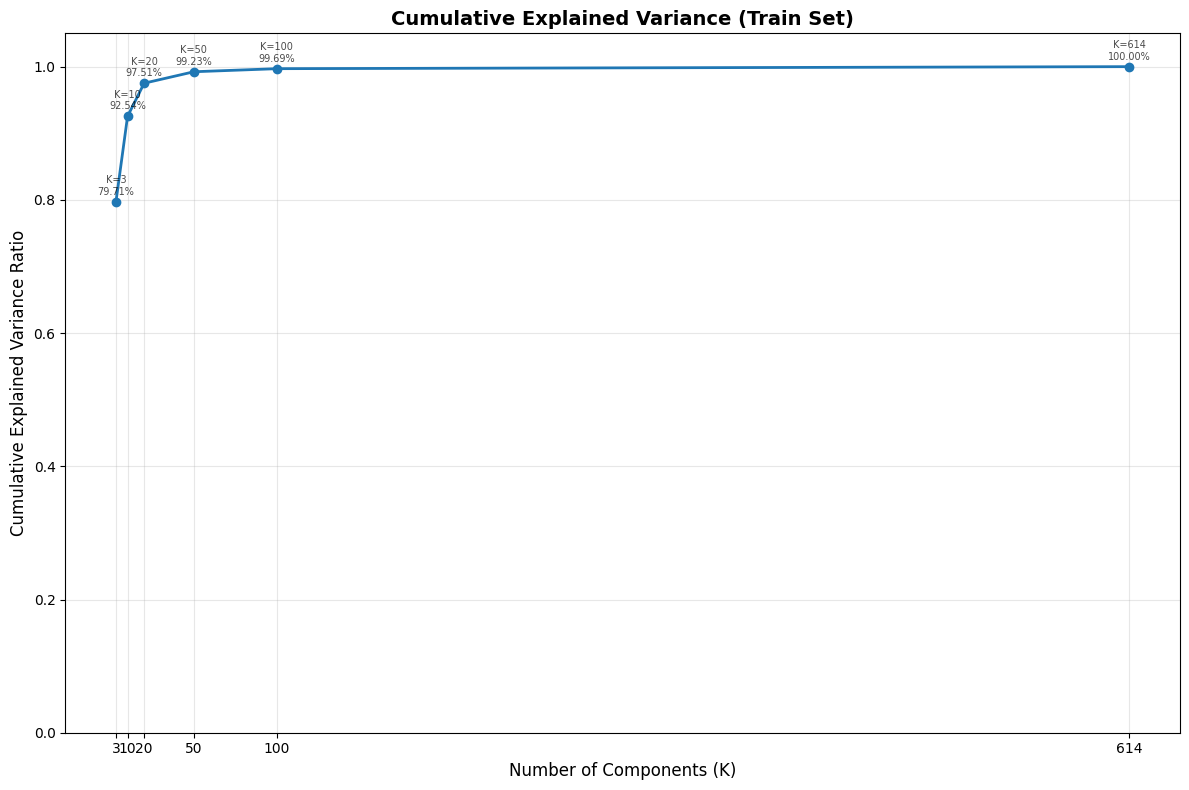

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\plots\reconstruction_errors_train_matrix.png


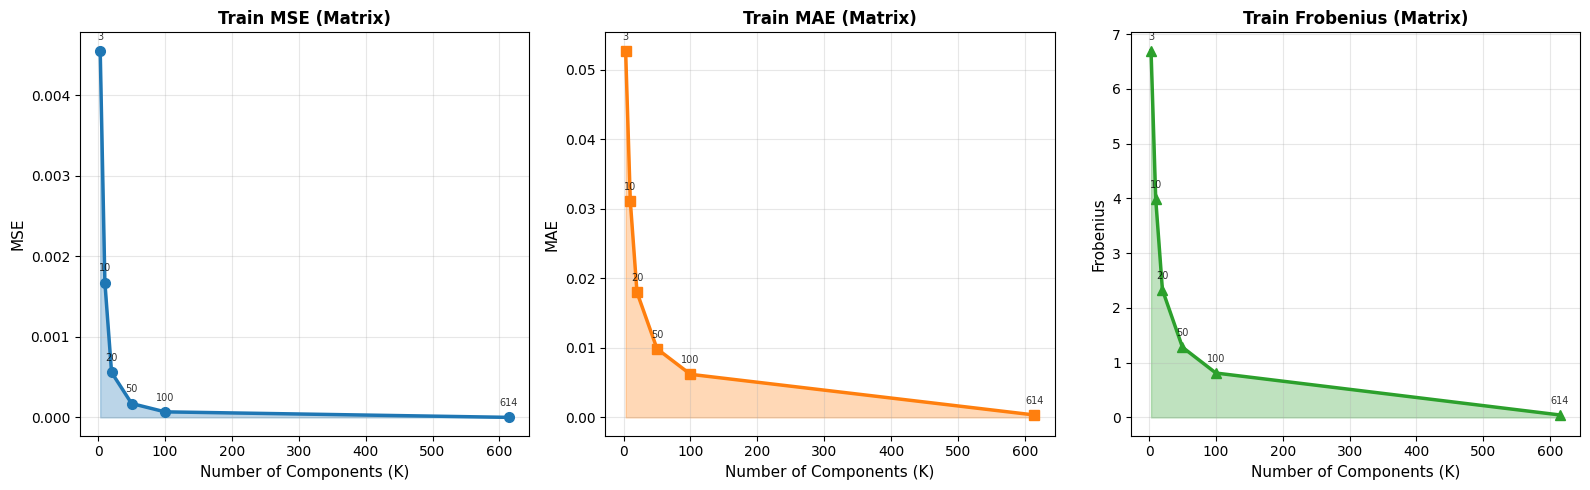

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\plots\reconstruction_errors_val_matrix.png


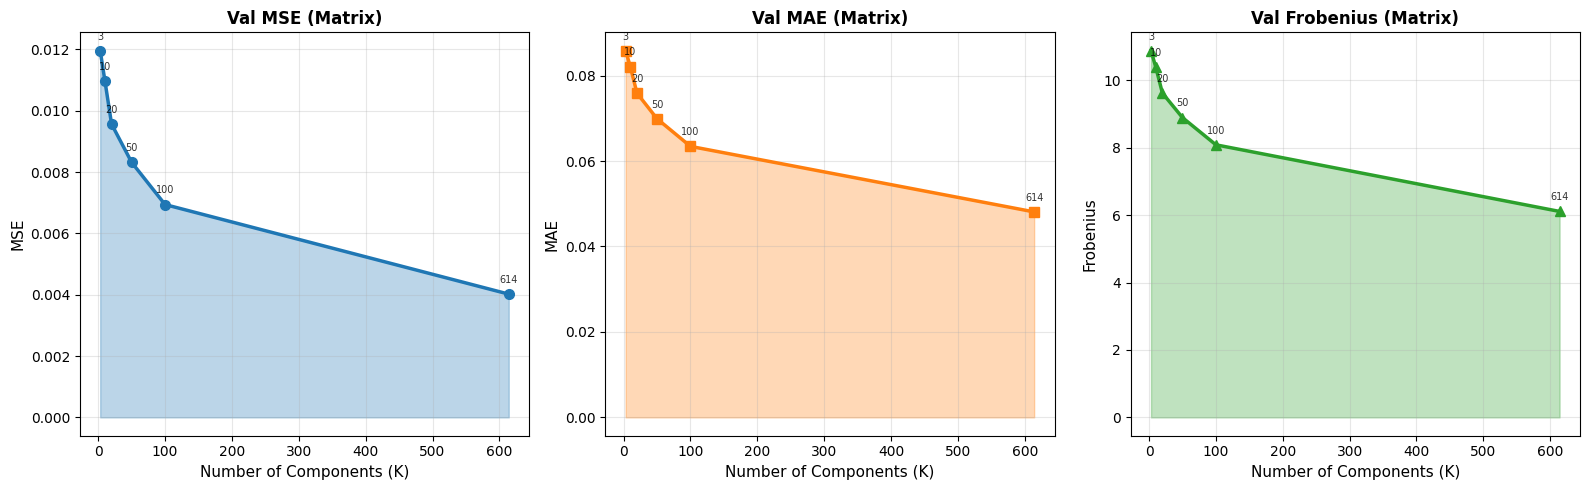

Saved plot: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\21_days_gap\PCA\plots\reconstruction_errors_test_matrix.png


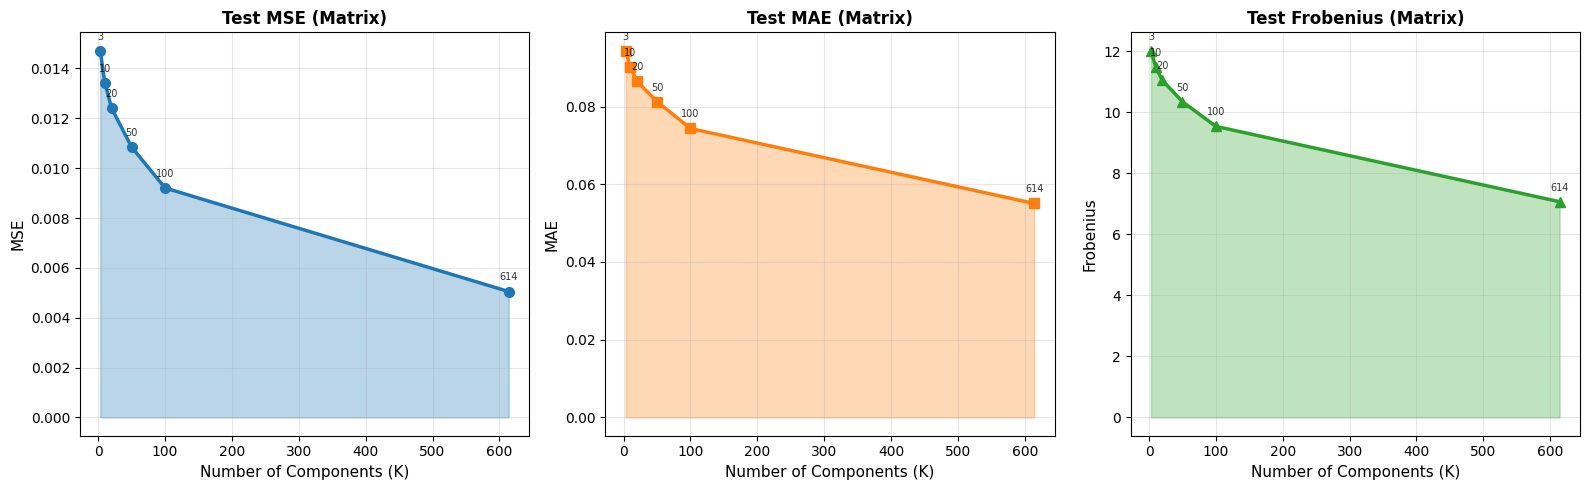

In [20]:

# Plot 1: Cumulative Explained Variance (train fit)
plot_dir = Path(f'../models/{FILE_NAME}_w{WINDOW_SIZE}_s{STRIDE}/{FORWARD_DAYS}_days_gap/PCA/plots')
plot_dir.mkdir(parents=True, exist_ok=True)

fig1, ax1 = plt.subplots(figsize=(12, 8))

k_values = sweep_df['n_components'].to_numpy()
mean_cum_var = sweep_df['mean_explained_variance'].to_numpy()
ax1.plot(k_values, mean_cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for k, val in zip(k_values, mean_cum_var):
    ax1.annotate(f'K={int(k)}\n{val*100:.2f}%',
                 xy=(k, val),
                 xytext=(0, 5),
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title(f'Cumulative Explained Variance (Train Set)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Components (K)', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
plt.tight_layout()

fig1_path = plot_dir / 'cumulative_explained_variance.png'
fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig1_path.resolve()}')

plt.show()

# ==========================================
# Plot 2: Train matrix errors (MSE/MAE/Frobenius)
# ==========================================
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_MSE_mean']):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[0].set_title(f'Train MSE (Matrix)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Components (K)', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_MAE_mean']):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[1].set_title(f'Train MAE (Matrix)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components (K)', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Train_matrix_Frobenius_mean']):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes[2].set_title(f'Train Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Components (K)', fontsize=11)
axes[2].set_ylabel('Frobenius', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

fig2_path = plot_dir / 'reconstruction_errors_train_matrix.png'
fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig2_path.resolve()}')

plt.show()

# ==========================================
# Plot 3: Val matrix errors (MSE/MAE/Frobenius)
# ==========================================
fig3, axes_val = plt.subplots(1, 3, figsize=(16, 5))

axes_val[0].plot(sweep_df['n_components'], sweep_df['Val_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes_val[0].fill_between(sweep_df['n_components'], sweep_df['Val_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Val_matrix_MSE_mean']):
    axes_val[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_val[0].set_title(f'Val MSE (Matrix)', fontsize=12, fontweight='bold')
axes_val[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_val[0].set_ylabel('MSE', fontsize=11)
axes_val[0].grid(True, alpha=0.3)

axes_val[1].plot(sweep_df['n_components'], sweep_df['Val_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_val[1].fill_between(sweep_df['n_components'], sweep_df['Val_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Val_matrix_MAE_mean']):
    axes_val[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_val[1].set_title(f'Val MAE (Matrix)', fontsize=12, fontweight='bold')
axes_val[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_val[1].set_ylabel('MAE', fontsize=11)
axes_val[1].grid(True, alpha=0.3)

axes_val[2].plot(sweep_df['n_components'], sweep_df['Val_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_val[2].fill_between(sweep_df['n_components'], sweep_df['Val_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Val_matrix_Frobenius_mean']):
    axes_val[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_val[2].set_title(f'Val Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes_val[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_val[2].set_ylabel('Frobenius', fontsize=11)
axes_val[2].grid(True, alpha=0.3)

plt.tight_layout()

fig3_path = plot_dir / 'reconstruction_errors_val_matrix.png'
fig3.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig3_path.resolve()}')

plt.show()

# ==========================================
# Plot 4: Test matrix errors (MSE/MAE/Frobenius)
# ==========================================
fig4, axes_test = plt.subplots(1, 3, figsize=(16, 5))

axes_test[0].plot(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes_test[0].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean'], alpha=0.3, color='#1f77b4')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_MSE_mean']):
    axes_test[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_test[0].set_title(f'Test MSE (Matrix)', fontsize=12, fontweight='bold')
axes_test[0].set_xlabel('Number of Components (K)', fontsize=11)
axes_test[0].set_ylabel('MSE', fontsize=11)
axes_test[0].grid(True, alpha=0.3)

axes_test[1].plot(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes_test[1].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean'], alpha=0.3, color='#ff7f0e')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_MAE_mean']):
    axes_test[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_test[1].set_title(f'Test MAE (Matrix)', fontsize=12, fontweight='bold')
axes_test[1].set_xlabel('Number of Components (K)', fontsize=11)
axes_test[1].set_ylabel('MAE', fontsize=11)
axes_test[1].grid(True, alpha=0.3)

axes_test[2].plot(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes_test[2].fill_between(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean'], alpha=0.3, color='#2ca02c')
for n_comp, val in zip(sweep_df['n_components'], sweep_df['Test_matrix_Frobenius_mean']):
    axes_test[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=7, alpha=0.8)
axes_test[2].set_title(f'Test Frobenius (Matrix)', fontsize=12, fontweight='bold')
axes_test[2].set_xlabel('Number of Components (K)', fontsize=11)
axes_test[2].set_ylabel('Frobenius', fontsize=11)
axes_test[2].grid(True, alpha=0.3)

plt.tight_layout()

fig4_path = plot_dir / 'reconstruction_errors_test_matrix.png'
fig4.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f'Saved plot: {fig4_path.resolve()}')
plt.show()